In [1]:
import numpy as np
import matplotlib.pyplot as plt
import LAMINAR
from sklearn.datasets import make_moons
import torch

#https://www.geeksforgeeks.org/k-means-clustering-introduction/

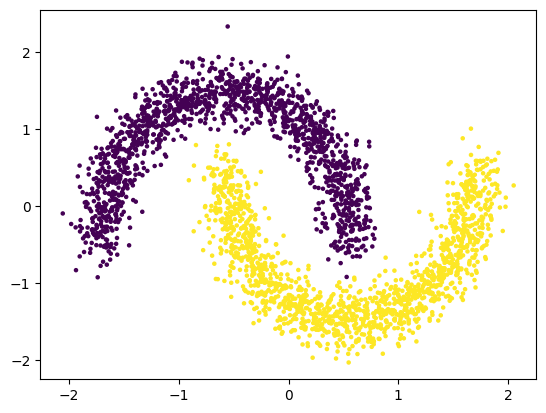

In [2]:
# make 2 moons data set
X, y = make_moons(n_samples=3000, noise=0.1)
X = (X-X.mean(axis=0))/X.std(axis=0)

data = torch.tensor(X, dtype=torch.float32)

# plot the data set
plt.scatter(X[:, 0], X[:, 1], c=y, s=5)

In [3]:
LAM = LAMINAR.LAMINAR(data, drop_freq=9999, epochs=5000)

Iteration 0 | Train Loss: 1713.16748046875 | Validation Loss: 1713.6397705078125
Iteration 99 | Train Loss: 273.16900634765625 | Validation Loss: 273.8792724609375
Iteration 199 | Train Loss: 231.461181640625 | Validation Loss: 227.59548950195312
Iteration 299 | Train Loss: 226.79588317871094 | Validation Loss: 220.60414123535156
Iteration 399 | Train Loss: 217.7267608642578 | Validation Loss: 212.73902893066406
Iteration 499 | Train Loss: 213.656494140625 | Validation Loss: 206.9174041748047
Iteration 599 | Train Loss: 210.11085510253906 | Validation Loss: 204.9634246826172
Iteration 699 | Train Loss: 191.7456817626953 | Validation Loss: 189.92269897460938
Iteration 799 | Train Loss: 191.19479370117188 | Validation Loss: 187.86795043945312
Iteration 899 | Train Loss: 187.8201446533203 | Validation Loss: 183.63551330566406
Iteration 999 | Train Loss: 188.03558349609375 | Validation Loss: 185.8189697265625
Iteration 1099 | Train Loss: 187.12655639648438 | Validation Loss: 184.3161315917

In [4]:
def distance_euclidean(x, y):
    return np.sqrt(np.sum((x-y)**2))

In [ ]:
def k_means(data, k, distance, epochs=1000):
    n = data.shape[0]
    m = data.shape[1]
    centroids = np.random.rand(k, m)
    for _ in range(epochs):
        clusters = [[] for _ in range(k)]
        for i in range(n):
            distances = [distance(data[i], centroids[j]) for j in range(k)]
            clusters[np.argmin(distances)].append(i)
        for j in range(k):
            if len(clusters[j]) > 0:
                centroids[j] = np.mean(data[clusters[j]], axis=0) # np.mean assumes euclidean geometry. LAMINAR is not applicable here
    return centroids, clusters

In [6]:
cen, clust = k_means(X, 2, distance_euclidean, 1000)

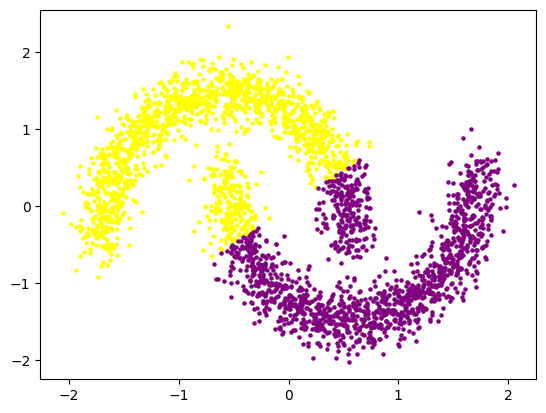

In [7]:
# plot
plt.figure()
plt.scatter(X[clust[0], 0], X[clust[0], 1], c='yellow', s=5)
plt.scatter(X[clust[1], 0], X[clust[1], 1], c='purple', s=5)


In [ ]:
# get kdtrees
from scipy.spatial import KDTree

def k_means_LAM(data, k, epochs=1000):
    n = data.shape[0]
    d = data.shape[1]
    centroids = torch.rand(k, d)
    for _ in range(epochs):
        # call query; return idx, the indices of the closest points in increasing order for the centroids, and dists, the distances of the respective point
        idx, dists = LAM.query(centroids)

        #kdt = KDTree(data)
        #dists, idx = kdt.query(centroids, k=n)

        #print(idx, dists)   
        # make tensors
        #dists = torch.tensor(dists, dtype=torch.float32)
        #idx = torch.tensor(idx, dtype=torch.int64)

        #print(idx, dists)
       # filter out the idx and dists with idx larger than n
        dists = dists[idx < n].reshape(d, n)

        #print(idx, dists)

        # sort idx and dists by idx
        idx, sort_idx = torch.sort(idx, dim=1)
        for i in range(k):
            dists[i] = dists[i, sort_idx[i]]

        #print(idx, dists)

        dists = dists.T
        idx = idx.T

        #print(idx, dists)

        # for each point, check which cluster it should be assigned to
        clusters = [[] for _ in range(d)]

        for i in range(n):
            # get argmin of dists[i]
            #print(dists[i])
            cluster = torch.argmin(dists[i]).item()
            #print(cluster)
            clusters[cluster].append(i)

        # update centroids
        for j in range(d):
            if len(clusters[j]) > 0:
                centroids[j] = torch.mean(data[clusters[j]], dim=0)
                
    return centroids, clusters

In [19]:
cen, clus = k_means_LAM(data, 2, 200)

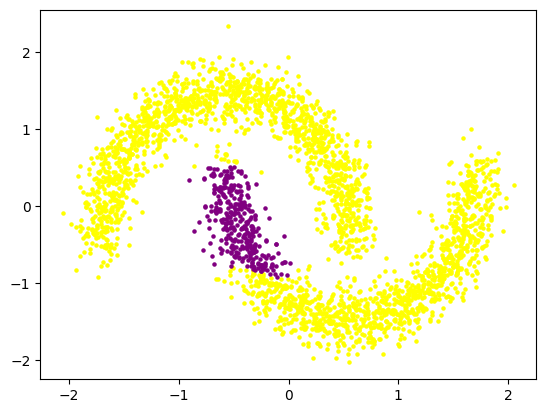

In [20]:
# plot
plt.figure()
plt.scatter(data[clus[0], 0], data[clus[0], 1], c='yellow', s=5)
plt.scatter(data[clus[1], 0], data[clus[1], 1], c='purple', s=5)
plt.show()

In [21]:
len(clus[1])

340

In [22]:
cen

tensor([[ 0.0577,  0.0287],
        [-0.4517, -0.2242]])